In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

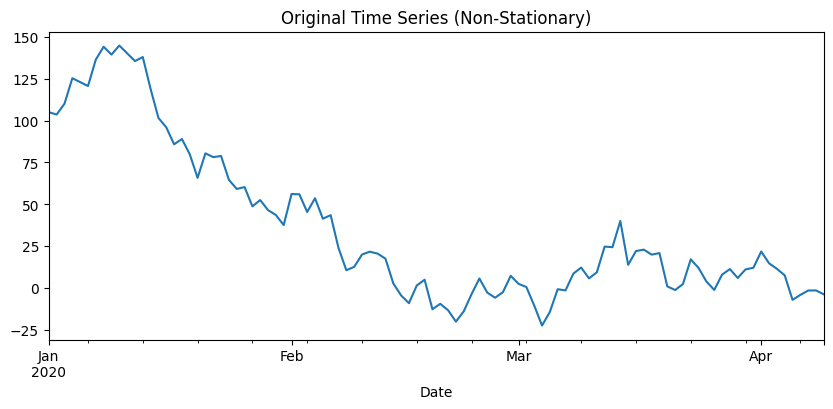

In [15]:
#1. 예제 데이터 생성(비정상 데이터)
np.random.seed(42)
date_range = pd.date_range(start="2020-01-01", periods=100, freq="D")
data = np.cumsum(np.random.randn(100)*10)+100 # 랜덤위크(비정상성 유발)
ts = pd.DataFrame({"Date":date_range, "Value":data}).set_index("Date")

# 시각화
plt.figure(figsize=(10,4))
ts["Value"].plot(title="Original Time Series (Non-Stationary)")
plt.show()

In [16]:
## 비정상성 ADF Test
def adf_test(series):
    result=adfuller(series)
    print(f"ADF Stastics : {result[0]:.4f}")
    print(f"P-Value : {result[1]:.4f}")
    print('Stationary' if result[1]<0.05 else 'Non-Stationary')

adf_test(ts)

ADF Stastics : -1.3583
P-Value : 0.6021
Non-Stationary


In [17]:
## 차분을 통해서 정상성을 변환
## diff 정상성 변환

ts_diff=ts.diff().dropna()
adf_test(ts_diff)

## 정상성으로 변환확인

ADF Stastics : -10.0089
P-Value : 0.0000
Stationary


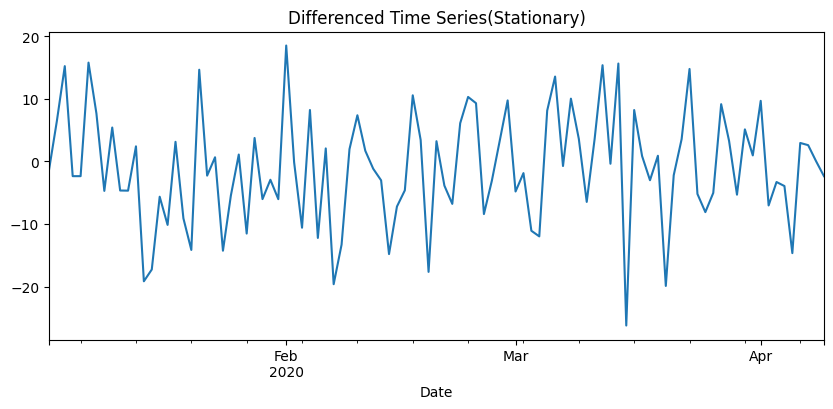

In [18]:
## 정상성이 어떤 모양일지?(차분후)
plt.figure(figsize=(10,4))
ts_diff['Value'].plot(title='Differenced Time Series(Stationary)')
plt.show()

In [21]:
## ARIMA모델학습 및 예측
model =ARIMA(ts['Value'], order=(1,1,1)) # 차분 1번
model_fit = model.fit()
# 예측
ts['Forecast']=model_fit.predict(start=len(ts)-10, end=len(ts)-1, dynamic=False)

D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


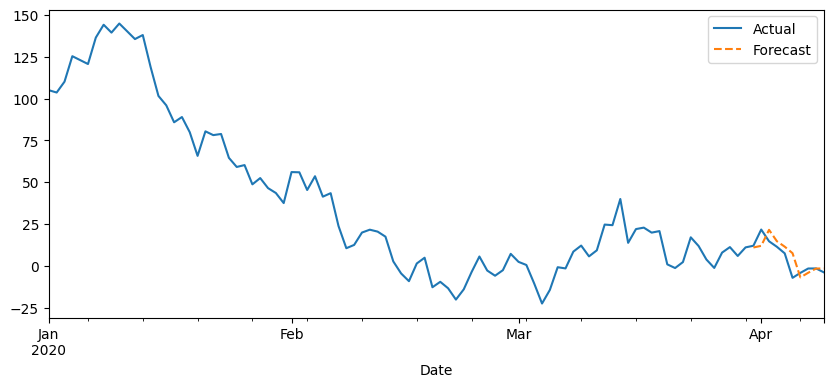

In [22]:
## 예측한 시각화
plt.figure(figsize=(10,4))
ts['Value'].plot(label='Actual')
ts['Forecast'].plot(label='Forecast', linestyle='dashed')
plt.legend()
plt.show()

In [24]:
## TimeSeriesSplit 교차검증
ts_split=TimeSeriesSplit(n_splits=5)
y_true, y_pred = [], []

for train_idx, test_idx in ts_split.split(ts):
    train, test = ts.iloc[train_idx], ts.iloc[test_idx]
    model = ARIMA(train['Value'], order=(1,1,1)).fit()
    pred = model.forecast(steps=len(test))
    y_true.extend(test['Value'].values)
    y_pred.extend(pred.values)

# MAE 계싼
mae=mean_absolute_error(y_true, y_pred)
print(f'Time Series Cross-Validation MAE : {mae:.4f}')

D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
D:\anaconda3\Lib\site-packages\stat

Time Series Cross-Validation MAE : 16.6015


D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
D:\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


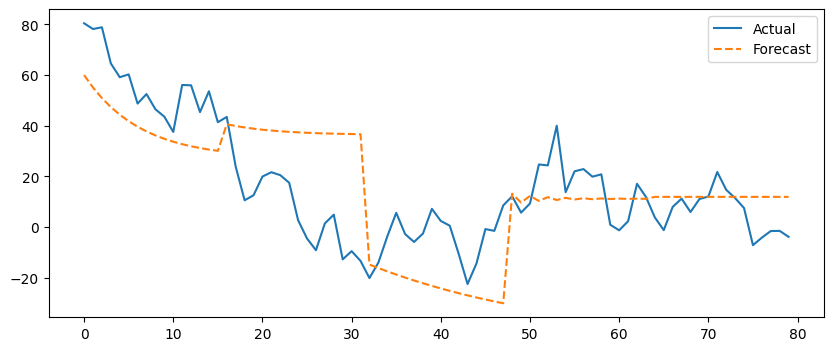

In [25]:
# 최종 예측 시각화
plt.figure(figsize=(10,4))
plt.plot(y_true, label='Actual')
plt.plot(y_pred, label='Forecast', linestyle='dashed')
plt.legend()
plt.show()

### **Auto-Arima**
- 최적의 ARIMA모델을 찾기 위해 자동으로 여러 테스트를 진행
- 특정값을 줄텐데 그 값은 (p,d,q)모델의 값을 줄 것
- AIC기준으로 선정

In [28]:
from pmdarima import auto_arima

optimal_arima_model = auto_arima(ts["Value"], seasonal=False, stepwise =  True, trace=True)
print(optimal_arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.84 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=721.347, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=723.302, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=723.297, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=720.793, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=725.138, Time=0.24 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.302 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  100
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -359.396
Date:                Fri, 07 Feb 2025   AIC                            720.793
Time:                        14:36:35   BIC                            723.388
Sample:                    01-01-2020   HQIC                           721.843
                    